## Slides RL 3b
- Ok in part 2 I found what I think should be a pretty productive set of examples
- Now I can start printing stuff for slides
- I believe there's a scaling issue in here impacting the reported probs, I don't think it's a huge problem, on a tight deadeline for pres tomorrow, going to keep moving and see if we can ignore for now (seems like things even out?), but should come back at some point. Part 2 has more details. 

In [1]:
BLUE="#2ca3dd"
YELLOW="#ffd35a"
RED='#ec2027'
CHILL_BROWN="#948979"

In [2]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
from matplotlib.path import Path
from matplotlib.markers import MarkerStyle
from matplotlib.patches import FancyBboxPatch, Circle
# from pathlib import Path
import os

import matplotlib.colors as mcolors
cmap = mcolors.LinearSegmentedColormap.from_list("blue_gold", [BLUE, YELLOW], N=256)

In [3]:
def style_ax(ax, color=CHILL_BROWN):
    ax.spines[:].set_color(color)
    ax.tick_params(colors=color, which='both')
    ax.xaxis.label.set_color(color)
    ax.yaxis.label.set_color(color)
    ax.title.set_color(color)


def arrow_path(direction=1, shaft_w=0.28, head_w=0.9, head_len=0.9, total_len=2.0):
    hl = head_len; sw = shaft_w/2; hw = head_w/2; L = total_len/2
    verts = np.array([
        (-L,  sw), (L-hl,  sw), (L-hl,  hw), (L, 0),
        (L-hl, -hw), (L-hl, -sw), (-L, -sw), (-L, sw),
    ]) * direction   # direction=-1 mirrors -> left arrow
    codes = [Path.MOVETO] + [Path.LINETO]*6 + [Path.CLOSEPOLY]
    return Path(verts, codes)

In [47]:
# HACKIN_DIR = '/Volumes/hot_1/Stephencwelch Dropbox/welch_labs/rl_1/hackin'
HACKIN_DIR = '/Users/stephen/Library/CloudStorage/Dropbox-Stephencwelch/welch_labs/rl_1/hackin'

In [48]:
VEL_SCALE = 10   # divide all velocities by 10 -> feature scales comparable, ~isotropic parameter space

In [49]:
CART_W, CART_H, POLE_LEN, WHEEL_R = 0.5, 0.26, 1.0, 0.07

def draw_cartpole(ax, cart_x, pole_theta, action=None):
    ax.set_xlim(-2.4, 2.4); ax.set_ylim(-0.55, 1.75)
    ax.set_aspect('equal'); ax.axis('off')
    ax.plot([-2.4, 2.4], [0, 0], color=CHILL_BROWN, lw=1.5, zorder=1)   # track
    cart_y = WHEEL_R*2
    for dx in (-CART_W*0.3, CART_W*0.3):
        ax.add_patch(Circle((cart_x+dx, WHEEL_R), WHEEL_R, color=CHILL_BROWN, zorder=3))
    ax.add_patch(FancyBboxPatch((cart_x-CART_W/2, cart_y), CART_W, CART_H,
                 boxstyle="round,pad=0.02,rounding_size=0.05",
                 fc='#3a3a3a', ec=CHILL_BROWN, lw=1.5, zorder=4))
    px, py = cart_x, cart_y + CART_H
    ax.plot([px, px + POLE_LEN*np.sin(pole_theta)],
            [py, py + POLE_LEN*np.cos(pole_theta)],
            color='w', lw=6, solid_capstyle='round', zorder=5)
    ax.add_patch(Circle((px, py), 0.045, color=CHILL_BROWN, zorder=6))
    if action is not None:   # action arrow under the cart, your color convention
        ax.scatter([cart_x], [-0.32],
                   marker=(RIGHT_ARROW if action==1 else LEFT_ARROW), s=420,
                   color=(YELLOW if action==1 else BLUE), linewidths=0, zorder=5)

In [50]:
RIGHT_ARROW = MarkerStyle(arrow_path(+1))
LEFT_ARROW  = MarkerStyle(arrow_path(-1))

ANG_LIM = (-13, 13) #Ok I want this to be in degrees!
VEL_LIM = (-17, 17)   # angvel data is pre-divided by VEL_SCALE=10

## 0. Some setup and baselines

In [51]:
# class Pi(nn.Module):
#     """Two-parameter policy: logit = theta1 * pole_angle + theta2 * pole_ang_velocity.

#     P(right) = sigmoid(logit). Returns [P(left), P(right)] with shape (2,) or (T, 2),
#     so the REINFORCE loop below is unchanged from the neural net version.
#     """
#     def __init__(self):
#         super().__init__()
#         self.theta = nn.Parameter(torch.zeros(2))  # [theta1, theta2] -> uniform random policy at init

#     def forward(self, x):
#         feats = x[..., 2:4]                # state indices 2, 3: pole angle, pole angular velocity
#         logit = feats @ self.theta         # scalar or (T,)
#         p_right = torch.sigmoid(logit)
#         return torch.stack([1.0 - p_right, p_right], dim=-1)

In [52]:
# This might be cleaner scaling wise, but I have a good amount of tech debt doing it the other way
# let me see if I can get the job done w/o this. 

class Pi(nn.Module):
    def __init__(self):
        super().__init__()
        self.theta = nn.Parameter(torch.zeros(2))

    def forward(self, x):
        feats = x[..., 2:4] * (180 / np.pi)   # degree-scale features
        logit = feats @ self.theta
        p_right = torch.sigmoid(logit)
        return torch.stack([1.0 - p_right, p_right], dim=-1)

In [53]:
def scale_state(s):
    s = s.astype(np.float32).copy()
    s[1] /= VEL_SCALE; s[3] /= VEL_SCALE   # same /10 velocity scaling as the demo data
    return s

def run_rollout(seed, deterministic=False):
    # --- rollout: collect one episode ---
    states, actions, rewards = [], [], []
    state, _ = env.reset(seed=seed)
    state = scale_state(state)
    for t in range(500):                                # CartPole-v1 max timestep is 500
        with torch.no_grad():                           # no graph needed here; we recompute below
            probs = pi(torch.from_numpy(state))

        if deterministic:
            action=probs.argmax().item() #Armax instead of sample!
        else:
            action = np.random.choice(out_dim, p=probs.numpy())

        states.append(state)                            # note: stored states are velocity-scaled
        actions.append(action)
        state, reward, terminated, truncated, _ = env.step(action)
        state = scale_state(state)
        rewards.append(reward)
        if terminated or truncated:
            break

    return states, actions, rewards

In [54]:
env = gym.make('CartPole-v1')
out_dim = env.action_space.n              
gamma=1.0

torch.manual_seed(52)
np.random.seed(52)
pi = Pi()

# pi.theta=nn.Parameter(torch.tensor([0.1, 0.2]))

# optimizer = optim.Adam(pi.parameters(), lr=0.05)  # 2 params only -> larger lr than the NN version
# optimizer = optim.SGD(pi.parameters(), lr=0.007)  # plain SGD: steps follow raw gradient direction (better for viz)
optimizer = optim.SGD(pi.parameters(), lr=0.00005)  # plain SGD: steps follow raw gradient direction (better for viz)

In [55]:
total_rewards = []

for epi in tqdm(range(500)):

    states, actions, rewards = run_rollout(seed=epi)
    # --- discounted returns-to-go: G_t = r_t + gamma * G_{t+1}, computed backwards ---
    T = len(rewards)
    rets = np.empty(T, dtype=np.float32)
    future_ret = 0.0
    for t in reversed(range(T)):
        future_ret = rewards[t] + gamma * future_ret
        rets[t] = future_ret
    rets = torch.tensor(rets)
    
    # rets = (rets - rets.mean()) / (rets.std() + 1e-8)   # baseline + variance normalization

    # --- REINFORCE update: one batched forward over the whole episode ---
    state_batch = torch.tensor(np.array(states, dtype=np.float32))   # (T, 4)
    action_batch = torch.tensor(actions)                              # (T,)
    prob_batch = pi(state_batch)                                      # (T, 2)
    act_probs = prob_batch[torch.arange(T), action_batch]             # prob of each action actually taken
    
    loss = -(torch.log(act_probs) * rets).sum()
    # loss = -(act_probs * rets).sum()
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_rewards.append(sum(rewards))

100%|████████████████████████████████████████| 500/500 [00:03<00:00, 159.59it/s]


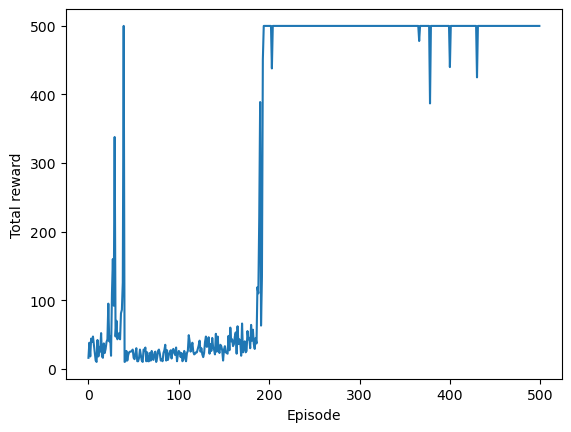

In [56]:
plt.plot(total_rewards)
plt.xlabel('Episode')
plt.ylabel('Total reward');

### 1 Stochastic Sweep 

In [57]:
# num_samples=32
# num_steps=32

# theta1_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps)
# theta2_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps) 

# all_rewards=[]

# for t1 in tqdm(theta1_vals_viz):
#     all_rewards.append([])
#     for t2 in theta2_vals_viz:
#         all_rewards[-1].append([])
#         for i in range(num_samples):
#             pi = Pi()
#             pi.theta=nn.Parameter(torch.tensor([t1.item(), t2.item()]))
#             states, actions, rewards = run_rollout(seed=i, deterministic=False) 
#             all_rewards[-1][-1].append(np.sum(rewards).item())
# all_rewards=np.array(all_rewards)

In [58]:
# Load from disk
all_rewards = np.load(HACKIN_DIR+'/256_100_sto_2.npy')

In [59]:
avg_reward=np.mean(all_rewards, 2)
std_reward=np.std(all_rewards, 2)

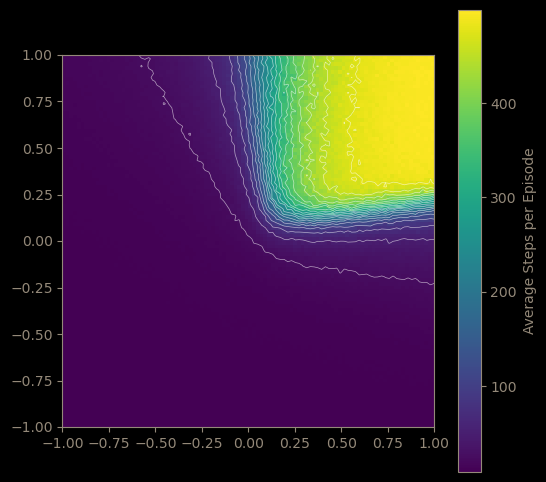

In [60]:
num_steps=all_rewards.shape[0]
theta1_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps)
theta2_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps) 

fig=plt.figure(0, (6,6), facecolor='k')
ax=fig.add_subplot(111)
extent=np.array([theta1_vals_viz[0], theta1_vals_viz[-1], theta2_vals_viz[0], theta2_vals_viz[-1]])
# im = ax.imshow(np.log(avg_reward.T), origin='lower', cmap='viridis',extent=np.radians(extent), aspect='equal') 
im = ax.imshow(avg_reward.T, origin='lower', cmap='viridis',extent=np.radians(extent), aspect='equal') 
T1, T2 = np.meshgrid(np.radians(theta1_vals_viz), np.radians(theta2_vals_viz))
cs = ax.contour(T1, T2, avg_reward.T, levels=20, colors='w', linewidths=0.5, alpha=0.6)
cb = fig.colorbar(im, ax=ax)
style_ax(ax)
cb.set_label('Average Steps per Episode', color=CHILL_BROWN)
cb.ax.yaxis.set_tick_params(color=CHILL_BROWN)
plt.setp(cb.ax.get_yticklabels(), color=CHILL_BROWN)
cb.outline.set_edgecolor(CHILL_BROWN)
plt.savefig(HACKIN_DIR+'/return_landscape_stochastic_3.png', dpi=240)

## 2. Render a collection of examples that I can show in a nice a grid

In [61]:
def draw_traj_panel(ax, ep):
    obs_e, act_e = ep['obs'], ep['act']
    ang, angvel = np.degrees(obs_e[:, 2]), np.degrees(obs_e[:, 3])
    A, V = np.meshgrid(np.linspace(*ANG_LIM, 160), np.linspace(*VEL_LIM, 160))
    P_right_grid = 1 / (1 + np.exp(-(t1 * A + t2 * V)))
    ax.imshow(P_right_grid, origin='lower', cmap=cmap, vmin=0, vmax=1,
              extent=[*ANG_LIM, *VEL_LIM], aspect='auto', alpha=0.4)
    ax.contour(A, V, P_right_grid, levels=[0.5], colors='w', linestyles='--', linewidths=1.5)
    ax.plot(ang, angvel, color='w', lw=1.0, alpha=0.25, zorder=3, solid_capstyle='round')
    m = act_e == 1
    ax.scatter(ang[m],  angvel[m],  marker=RIGHT_ARROW, s=180, color=YELLOW, alpha=0.85, linewidths=0, zorder=4)
    ax.scatter(ang[~m], angvel[~m], marker=LEFT_ARROW,  s=180, color=BLUE,   alpha=0.85, linewidths=0, zorder=4)
    made_it = len(act_e) == 500
    ax.scatter([ang[-1]], [angvel[-1]],
               marker=(RIGHT_ARROW if act_e[-1]==1 else LEFT_ARROW), s=260,
               facecolors='none', edgecolors=('w' if made_it else RED), linewidths=1.6, zorder=5)
    ax.text(0.02, 0.97, f'Steps = {len(act_e)}', transform=ax.transAxes,
            ha='left', va='top', color=CHILL_BROWN, fontsize=14)
    ax.set_xlim(*ANG_LIM); ax.set_ylim(*VEL_LIM)
    ax.set_xlabel('pole angle (degrees)'); ax.set_ylabel('pole angular velocity')
    ax.set_title('State Space'); style_ax(ax)

In [62]:
t1, t2 = -0.5, 0.00 #ok this actually feels pretty solid and explainable, lets go!!

pi = Pi()
pi.theta = nn.Parameter(torch.tensor([t1, t2]))     # set EXPLICITLY on pi itself
print('policy theta:', pi.theta.detach().numpy())

N_EPS = 1024
np.random.seed(0)
eps = []
for i in tqdm(range(N_EPS)):
    states, actions, rewards = run_rollout(seed=0, deterministic=False)  # seed=i -> same start dist as sweep
    eps.append({'obs': np.array(states), 'act': np.array(actions), 'R': float(np.sum(rewards))})
R = np.array([e['R'] for e in eps])
print(f'returns: mean {R.mean():.1f}  min {R.min():.0f}  max {R.max():.0f}')

policy theta: [-0.5  0. ]


100%|█████████████████████████████████████| 1024/1024 [00:00<00:00, 4202.29it/s]

returns: mean 10.0  min 8  max 28


In [63]:
# Probability of each rollout: product over timesteps of pi(a_t | s_t).
# Dynamics are deterministic + fixed start (seed=0), so this is the full rollout prob.
for ep in eps:
    state_batch  = torch.tensor(ep['obs'], dtype=torch.float32)   # (T, 4)
    action_batch = torch.tensor(ep['act'])                        # (T,)
    T = len(action_batch)

    with torch.no_grad():
        prob_batch = pi(state_batch)                              # (T, 2)
    act_probs = prob_batch[torch.arange(T), action_batch]         # prob of each action taken

    ep['log_prob'] = torch.log(act_probs).sum().item()            # log P(rollout)
    ep['prob']     = np.exp(ep['log_prob'])                       # P(rollout)

log_probs = np.array([e['log_prob'] for e in eps])
probs     = np.array([e['prob'] for e in eps])
print(f'log probs: mean {log_probs.mean():.1f}  min {log_probs.min():.1f}  max {log_probs.max():.1f}')
print(f'probs: min {probs.min():.2e}  max {probs.max():.2e}  sum {probs.sum():.2e}')

log probs: mean -3.3  min -17.9  max -0.9
probs: min 1.65e-08  max 3.91e-01  sum 1.73e+02


In [64]:
# For each rollout, compute:
#   prob:          P(rollout) = prod_t pi(a_t | s_t)
#   grad_log_prob: ∇θ log P(rollout) = Σ_t ∇θ log π(a_t|s_t)   (the REINFORCE direction)
#   grad_prob:     ∇θ P(rollout) = P(rollout) · ∇θ log P(rollout)
for ep in eps:
    state_batch  = torch.tensor(ep['obs'], dtype=torch.float32)   # (T, 4)
    action_batch = torch.tensor(ep['act'])                        # (T,)
    T = len(action_batch)

    prob_batch = pi(state_batch)                                  # (T, 2) — graph kept this time
    act_probs  = prob_batch[torch.arange(T), action_batch]
    log_prob   = torch.log(act_probs).sum()

    ep['log_prob'] = log_prob.item()
    ep['prob']     = np.exp(ep['log_prob'])
    ep['grad_log_prob'] = torch.autograd.grad(log_prob, pi.theta)[0].numpy()
    ep['grad_prob']     = ep['prob'] * ep['grad_log_prob']

grad_logs  = np.array([e['grad_log_prob'] for e in eps])   # (N_EPS, 2)
grad_probs = np.array([e['grad_prob'] for e in eps])
print('grad log prob: mean', grad_logs.mean(0), ' |max|', np.abs(grad_logs).max())
print('grad prob:     mean', grad_probs.mean(0), ' |max|', np.abs(grad_probs).max())

grad log prob: mean [0.03662129 0.0396847 ]  |max| 18.739346
grad prob:     mean [-0.4442312  -0.43908513]  |max| 1.1791118018088502


Text(0.5, 1.0, '0.0781477849285814')

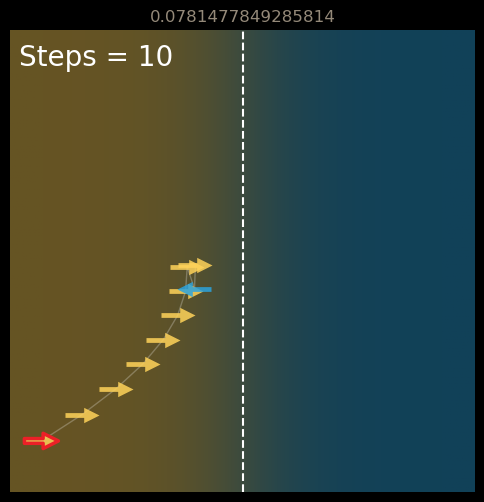

In [89]:
k=66

fig=plt.figure(0, (6, 6), facecolor='k')
ax=fig.add_subplot(111, facecolor='k')

ep=eps[k]
obs_e, act_e = ep['obs'], ep['act']
ang, angvel = np.degrees(obs_e[:, 2]), np.degrees(obs_e[:, 3])
A, V = np.meshgrid(np.linspace(*ANG_LIM, 160), np.linspace(*VEL_LIM, 160))
P_right_grid = 1 / (1 + np.exp(-(t1 * A + t2 * V)))
ax.imshow(P_right_grid, origin='lower', cmap=cmap, vmin=0, vmax=1,
          extent=[*ANG_LIM, *VEL_LIM], aspect='auto', alpha=0.4)
ax.contour(A, V, P_right_grid, levels=[0.5], colors='w', linestyles='--', linewidths=1.5)
ax.plot(ang, angvel, color='w', lw=1.0, alpha=0.25, zorder=3, solid_capstyle='round')
m = act_e == 1
ax.scatter(ang[m],  angvel[m],  marker=RIGHT_ARROW, s=600, color=YELLOW, alpha=0.85, linewidths=0, zorder=4)
ax.scatter(ang[~m], angvel[~m], marker=LEFT_ARROW,  s=600, color=BLUE,   alpha=0.85, linewidths=0, zorder=4)
made_it = len(act_e) == 500
ax.scatter([ang[-1]], [angvel[-1]],
           marker=(RIGHT_ARROW if act_e[-1]==1 else LEFT_ARROW), s=600,
           facecolors='none', edgecolors=('w' if made_it else RED), linewidths=2.5, zorder=5)
ax.text(0.02, 0.97, f'Steps = {len(act_e)}', transform=ax.transAxes,
        ha='left', va='top', color='w', fontsize=20)
ax.set_xlim(*ANG_LIM); ax.set_ylim(*VEL_LIM)
# ax.set_xlabel('pole angle (degrees)'); ax.set_ylabel('pole angular velocity')
# ax.set_title('State Space'); 
style_ax(ax)
plt.axis('off')
plt.title(ep['prob'])

## Animate Rollouts

In [130]:
# %% ---- Cell A ----
save_dir = HACKIN_DIR + '/stochastic_rollouts_anim_1'
os.makedirs(save_dir, exist_ok=True)

# %% ---- Cell B ----
# Which rollouts to animate -- all from theta=(-0.5, 0), seed=0 start (cells above).
# Use the hand-picked samples, or swap for e.g. list(range(16)) for the first 16.
# ANIM_EPS = samples
ANIM_EPS = list(range(16))

def anim_frames(T, dense_steps=60, max_frames=150):
    """Every step for the first dense_steps, then evenly-spaced steps so 500-step
    episodes don't generate thousands of frames -- since all points up to t are
    drawn each frame, this reads as a fast-forward with the step counter racing."""
    if T <= max_frames:
        return np.arange(T)
    tail = np.linspace(dense_steps, T-1, max_frames - dense_steps).astype(int)
    return np.unique(np.concatenate([np.arange(dense_steps), tail]))

print('total frames ~', sum(len(anim_frames(len(eps[k]['act']))) for k in ANIM_EPS))

total frames ~ 150


In [131]:
ANIM_EPS

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

In [132]:
# %% ---- Cell C ----
GLOBAL_COUNT=0
PERSIST_EPISODES=False    
TERMINAL_HOLD=7
history=[]

# policy background is fixed (same theta for every rollout) -- compute once
A, V = np.meshgrid(np.linspace(*ANG_LIM, 160), np.linspace(*VEL_LIM, 160))
P_right_grid = 1 / (1 + np.exp(-(t1 * A + t2 * V)))

for count, k in enumerate(tqdm(ANIM_EPS)):
    ep = eps[k]
    obs_e, act_e = ep['obs'], ep['act']
    ang    = np.degrees(obs_e[:, 2])
    angvel = np.degrees(obs_e[:, 3])
    made_it = len(act_e) == 500

    for t in anim_frames(len(obs_e)):
        fig, (ax, axR) = plt.subplots(1, 2, figsize=(13, 5.6), facecolor='k')
        ax.set_facecolor('k'); axR.set_facecolor('k')

        # ---- left: state space, same as sample_rollouts_2 loop but steps up to t ----
        ax.imshow(P_right_grid, origin='lower', cmap=cmap, vmin=0, vmax=1,
                  extent=[*ANG_LIM, *VEL_LIM], aspect='auto', alpha=0.4)
        ax.contour(A, V, P_right_grid, levels=[0.5], colors='w', linestyles='--', linewidths=1.5)

        if PERSIST_EPISODES:
            for h in history:
                ax.scatter(h['a'][h['m']],  h['v'][h['m']],  marker=RIGHT_ARROW, s=600, color=YELLOW, alpha=0.25, linewidths=0, zorder=3)
                ax.scatter(h['a'][~h['m']], h['v'][~h['m']], marker=LEFT_ARROW,  s=600, color=BLUE,   alpha=0.25, linewidths=0, zorder=3)

        m = act_e[:t+1] == 1
        a, v = ang[:t+1], angvel[:t+1]
        ax.plot(a, v, color='w', lw=1.0, alpha=0.25, zorder=3, solid_capstyle='round')
        ax.scatter(a[m],  v[m],  marker=RIGHT_ARROW, s=600, color=YELLOW, alpha=0.85, linewidths=0, zorder=4)
        ax.scatter(a[~m], v[~m], marker=LEFT_ARROW,  s=600, color=BLUE,   alpha=0.85, linewidths=0, zorder=4)

        is_terminal = (t == len(act_e)-1)
        ring_color = RED if (is_terminal and not made_it) else 'w'
        ax.scatter([ang[t]], [angvel[t]],
                   marker=(RIGHT_ARROW if act_e[t]==1 else LEFT_ARROW), s=600,
                   facecolors='none', edgecolors=ring_color, linewidths=2.5, zorder=5)

        ax.text(0.02, 0.97, f'Steps = {t+1}', transform=ax.transAxes,
                ha='left', va='top', color='w', fontsize=20)
        ax.set_xlim(*ANG_LIM); ax.set_ylim(*VEL_LIM)
        style_ax(ax)
        ax.set_xlabel(ep['prob'], color=CHILL_BROWN)

        # ---- right: cart pole game, same as slides_viz_2 section 7 ----
        draw_cartpole(axR, obs_e[t,0], obs_e[t,2], action=act_e[t])
        axR.text(0.5, -0.2, f'Step Number = {t}', transform=axR.transAxes,
                 ha='center', va='bottom', color=CHILL_BROWN, fontsize=14)
        axR.text(0.5, 1.02, f'Rollout {count+1}/{len(ANIM_EPS)}', transform=axR.transAxes,
                 ha='center', va='bottom', color=CHILL_BROWN, fontsize=14)
        plt.tight_layout()

        plt.savefig(save_dir + '/' + str(GLOBAL_COUNT).zfill(4) + '.png', dpi=240, facecolor='k')
        GLOBAL_COUNT+=1
        if is_terminal:
            for _ in range(TERMINAL_HOLD):
                plt.savefig(save_dir + '/' + str(GLOBAL_COUNT).zfill(4) + '.png', dpi=240, facecolor='k')
                GLOBAL_COUNT+=1
        plt.close(fig)

    if PERSIST_EPISODES:
        history.append({'a': ang, 'v': angvel, 'm': act_e == 1})

100%|███████████████████████████████████████████| 16/16 [00:49<00:00,  3.10s/it]


In [ ]:
# %% ---- Cell D ----
# ---- final cumulative frame: all animated rollouts at full opacity ----
fig, (ax, axR) = plt.subplots(1, 2, figsize=(13, 5.6), facecolor='k')
ax.set_facecolor('k'); axR.set_facecolor('k')

ax.imshow(P_right_grid, origin='lower', cmap=cmap, vmin=0, vmax=1,
          extent=[*ANG_LIM, *VEL_LIM], aspect='auto', alpha=0.4)
ax.contour(A, V, P_right_grid, levels=[0.5], colors='w', linestyles='--', linewidths=1.5)
for h in history:
    ax.scatter(h['a'][h['m']],  h['v'][h['m']],  marker=RIGHT_ARROW, s=600, color=YELLOW, alpha=0.85, linewidths=0, zorder=4)
    ax.scatter(h['a'][~h['m']], h['v'][~h['m']], marker=LEFT_ARROW,  s=600, color=BLUE,   alpha=0.85, linewidths=0, zorder=4)
ax.set_xlim(*ANG_LIM); ax.set_ylim(*VEL_LIM)
style_ax(ax)
axR.axis('off')
plt.tight_layout()
plt.savefig(save_dir + '/' + str(GLOBAL_COUNT).zfill(4) + '.png', dpi=240, facecolor='k')

print('done:', GLOBAL_COUNT+1, 'frames ->', save_dir)

## Four Rollouts

In [103]:
samples=[0, 32, 36, 124] #124, 307 
# samples=[0, 32, 66, 124] #124, 307 

In [104]:
for i in samples:
    print(R[i], eps[i]['prob'], eps[i]['grad_prob'], eps[i]['grad_log_prob'])

8.0 0.39075128021112177 [-1.15728721 -1.1791118 ] [-2.9616978 -3.0175507]
10.0 0.0613975854549827 [-0.09042743 -0.17266702] [-1.4728173 -2.812277 ]
10.0 0.0781477849285814 [-0.08722173 -0.07075481] [-1.1161126  -0.90539753]
22.0 1.7988163985037466e-07 [1.48441895e-06 8.27529807e-07] [8.252198 4.600413]


In [105]:
-0.00092297/1.11549698e-07

-8274.069912766594

In [106]:
-0.00028558/-3.93676217e-06

72.54184725108756

- Hmm yeah going to have to get a bit creative with the scaling!
- I'm 50/50 on if we keep the 16 one, or just do 3 bad one good

In [107]:
GREEN='#00A14A'
ORANGE='#F26522'

colorz=[GREEN, ORANGE, YELLOW, BLUE]

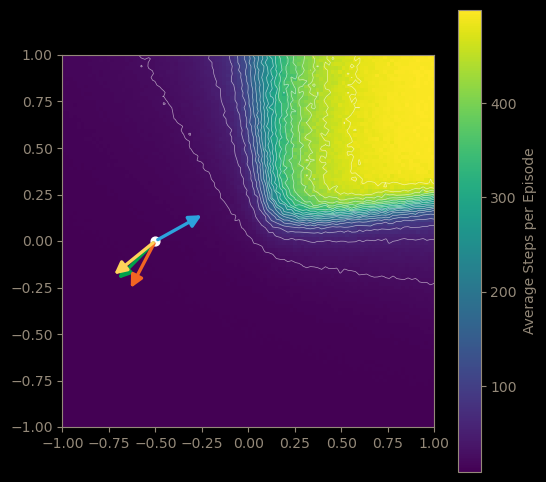

In [108]:
num_steps=all_rewards.shape[0]
theta1_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps)
theta2_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps) 

fig=plt.figure(0, (6,6), facecolor='k')
ax=fig.add_subplot(111)
extent=np.array([theta1_vals_viz[0], theta1_vals_viz[-1], theta2_vals_viz[0], theta2_vals_viz[-1]])
# im = ax.imshow(np.log(avg_reward.T), origin='lower', cmap='viridis',extent=np.radians(extent), aspect='equal') 
im = ax.imshow(avg_reward.T, origin='lower', cmap='viridis',extent=np.radians(extent), aspect='equal') 
T1, T2 = np.meshgrid(np.radians(theta1_vals_viz), np.radians(theta2_vals_viz))
cs = ax.contour(T1, T2, avg_reward.T, levels=20, colors='w', linewidths=0.5, alpha=0.6)


viz_scale=0.3
for k, sample_index in enumerate(samples):
    grad=eps[sample_index]['grad_prob']
    ax.annotate('', xy=np.array([t1, t2]) + viz_scale*grad/np.linalg.norm(grad), xytext=(t1, t2), #zorder=7,
                arrowprops=dict(arrowstyle='-|>', color=colorz[k], lw=2.4, mutation_scale=18))

plt.scatter(t1, t2, c='w', s=40)

cb = fig.colorbar(im, ax=ax)
style_ax(ax)
cb.set_label('Average Steps per Episode', color=CHILL_BROWN)
cb.ax.yaxis.set_tick_params(color=CHILL_BROWN)
plt.setp(cb.ax.get_yticklabels(), color=CHILL_BROWN)
cb.outline.set_edgecolor(CHILL_BROWN)
plt.savefig(HACKIN_DIR+'/voting_1.png', dpi=240)

- Ok that's not so bad, and then scaling by rewards from here is a little cheaty, but not insane. 

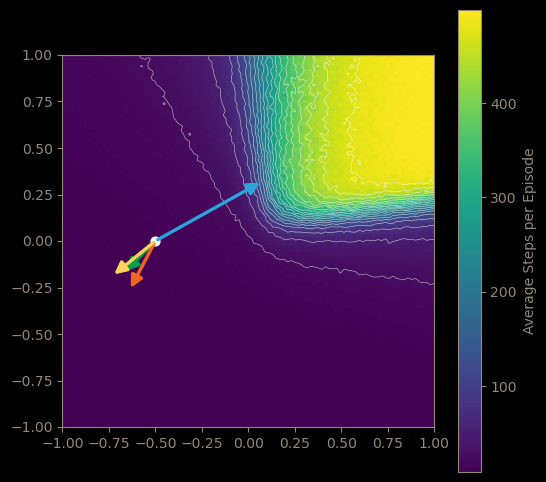

In [109]:
num_steps=all_rewards.shape[0]
theta1_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps)
theta2_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps) 

fig=plt.figure(0, (6,6), facecolor='k')
ax=fig.add_subplot(111)
extent=np.array([theta1_vals_viz[0], theta1_vals_viz[-1], theta2_vals_viz[0], theta2_vals_viz[-1]])
# im = ax.imshow(np.log(avg_reward.T), origin='lower', cmap='viridis',extent=np.radians(extent), aspect='equal') 
im = ax.imshow(avg_reward.T, origin='lower', cmap='viridis',extent=np.radians(extent), aspect='equal') 
T1, T2 = np.meshgrid(np.radians(theta1_vals_viz), np.radians(theta2_vals_viz))
cs = ax.contour(T1, T2, avg_reward.T, levels=20, colors='w', linewidths=0.5, alpha=0.6)


viz_scale=0.3/10
for k, sample_index in enumerate(samples):
    grad=eps[sample_index]['grad_prob']
    #Scale by length of run
    ax.annotate('', xy=np.array([t1, t2]) + R[sample_index]*viz_scale*grad/np.linalg.norm(grad), xytext=(t1, t2), #zorder=7,
                arrowprops=dict(arrowstyle='-|>', color=colorz[k], lw=2.4, mutation_scale=18))

plt.scatter(t1, t2, c='w', s=40)

cb = fig.colorbar(im, ax=ax)
style_ax(ax)
cb.set_label('Average Steps per Episode', color=CHILL_BROWN)
cb.ax.yaxis.set_tick_params(color=CHILL_BROWN)
plt.setp(cb.ax.get_yticklabels(), color=CHILL_BROWN)
cb.outline.set_edgecolor(CHILL_BROWN)
plt.savefig(HACKIN_DIR+'/voting_2.png', dpi=240)

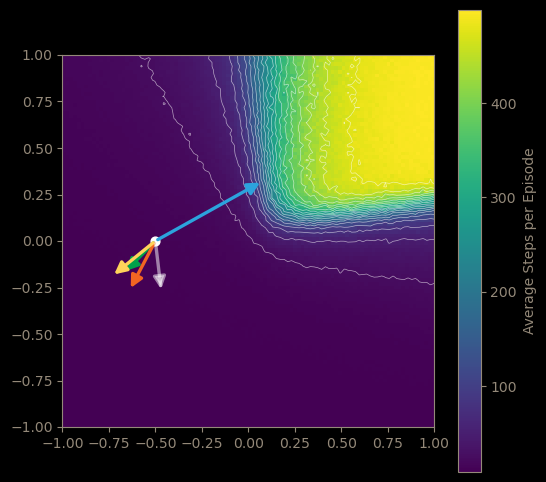

In [125]:
num_steps=all_rewards.shape[0]
theta1_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps)
theta2_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps) 

fig=plt.figure(0, (6,6), facecolor='k')
ax=fig.add_subplot(111)
extent=np.array([theta1_vals_viz[0], theta1_vals_viz[-1], theta2_vals_viz[0], theta2_vals_viz[-1]])
# im = ax.imshow(np.log(avg_reward.T), origin='lower', cmap='viridis',extent=np.radians(extent), aspect='equal') 
im = ax.imshow(avg_reward.T, origin='lower', cmap='viridis',extent=np.radians(extent), aspect='equal') 
T1, T2 = np.meshgrid(np.radians(theta1_vals_viz), np.radians(theta2_vals_viz))
cs = ax.contour(T1, T2, avg_reward.T, levels=20, colors='w', linewidths=0.5, alpha=0.6)


viz_scale=0.3/10
all_scaled_grads=[]
for k, sample_index in enumerate(samples):
    grad=eps[sample_index]['grad_prob']
    all_scaled_grads.append(R[sample_index]*viz_scale*grad/np.linalg.norm(grad))
    #Scale by length of run
    ax.annotate('', xy=np.array([t1, t2]) + R[sample_index]*viz_scale*grad/np.linalg.norm(grad), xytext=(t1, t2), #zorder=7,
                arrowprops=dict(arrowstyle='-|>', color=colorz[k], lw=2.4, mutation_scale=18))

all_scaled_grads=np.array(all_scaled_grads)
sum_scaled_grads=np.sum(all_scaled_grads, 0)
ax.annotate('', xy=np.array([t1, t2]) + 0.9*sum_scaled_grads, xytext=(t1, t2), #zorder=7,
            arrowprops=dict(arrowstyle='-|>', color='w', lw=2.4, mutation_scale=18, alpha=0.5))



plt.scatter(t1, t2, c='w', s=40)

cb = fig.colorbar(im, ax=ax)
style_ax(ax)
cb.set_label('Average Steps per Episode', color=CHILL_BROWN)
cb.ax.yaxis.set_tick_params(color=CHILL_BROWN)
plt.setp(cb.ax.get_yticklabels(), color=CHILL_BROWN)
cb.outline.set_edgecolor(CHILL_BROWN)
plt.savefig(HACKIN_DIR+'/voting_2.png', dpi=240)

In [119]:
sum_scaled_grads

array([-1.33493488, -1.42253281])

In [115]:
all_scaled_grads

array([[-1.15728721e+00, -1.17911180e+00],
       [-9.04274261e-02, -1.72667022e-01],
       [-8.72217266e-02, -7.07548118e-02],
       [ 1.48441895e-06,  8.27529807e-07]])

In [117]:
np.sum(all_scaled_grads, 0)

array([-1.33493488, -1.42253281])

- Ok cool yeah these still overpower, nice. Maybe that lead's to the really simple example, we'll see
- Ok that's 10 o'clock, will pickup at 4:30am, I think this intution will work, and then lead to the training animation and grant's math explanation.
- Ah yeah and we can scale by diving by p!

In [62]:
grad/np.linalg.norm(grad)

array([0.83060835, 0.55685705])

---

In [33]:
for i in samples:
    print(R[i], eps[i]['prob'], eps[i]['grad_prob'])

8.0 0.004277968470176871
9.0 0.002155133535956128
16.0 1.827722353412054e-05
20.0 8.69767434215215e-07


In [31]:
ep['prob']

np.float64(9.211103387732331e-07)

(np.float64(-13.0), np.float64(13.0), np.float64(-17.0), np.float64(17.0))

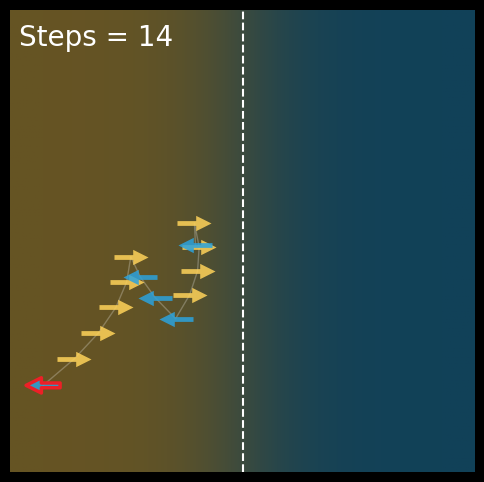

<Figure size 640x480 with 0 Axes>

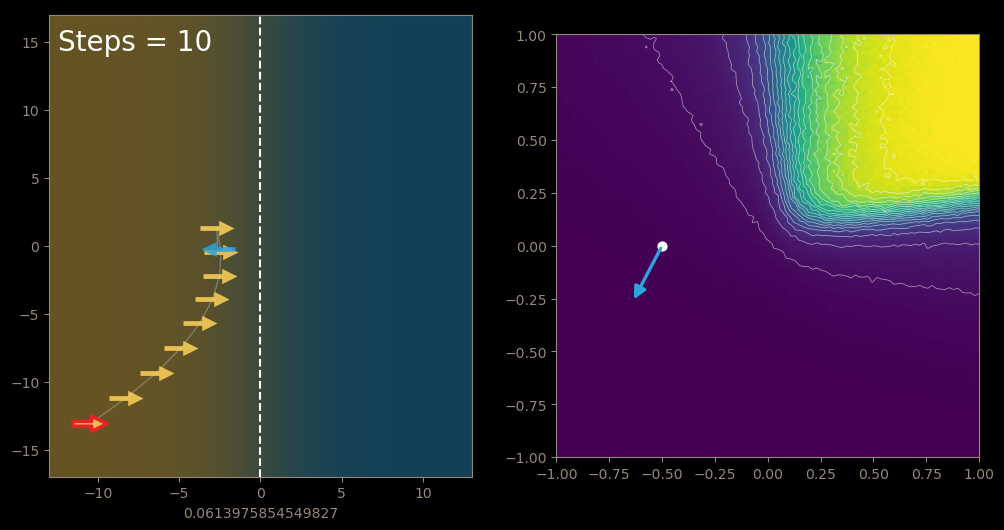

In [83]:
k=3
plt.clf()
fig=plt.figure(0, (12, 6), facecolor='k')
ax=fig.add_subplot(121, facecolor='k')
ax2=fig.add_subplot(122, facecolor='k')

ep=eps[k]
obs_e, act_e = ep['obs'], ep['act']
ang, angvel = np.degrees(obs_e[:, 2]), np.degrees(obs_e[:, 3])
A, V = np.meshgrid(np.linspace(*ANG_LIM, 160), np.linspace(*VEL_LIM, 160))
P_right_grid = 1 / (1 + np.exp(-(t1 * A + t2 * V)))
ax.imshow(P_right_grid, origin='lower', cmap=cmap, vmin=0, vmax=1,
          extent=[*ANG_LIM, *VEL_LIM], aspect='auto', alpha=0.4)
ax.contour(A, V, P_right_grid, levels=[0.5], colors='w', linestyles='--', linewidths=1.5)
ax.plot(ang, angvel, color='w', lw=1.0, alpha=0.25, zorder=3, solid_capstyle='round')
m = act_e == 1
ax.scatter(ang[m],  angvel[m],  marker=RIGHT_ARROW, s=600, color=YELLOW, alpha=0.85, linewidths=0, zorder=4)
ax.scatter(ang[~m], angvel[~m], marker=LEFT_ARROW,  s=600, color=BLUE,   alpha=0.85, linewidths=0, zorder=4)
made_it = len(act_e) == 500
ax.scatter([ang[-1]], [angvel[-1]],
           marker=(RIGHT_ARROW if act_e[-1]==1 else LEFT_ARROW), s=600,
           facecolors='none', edgecolors=('w' if made_it else RED), linewidths=2.5, zorder=5)
ax.text(0.02, 0.97, f'Steps = {len(act_e)}', transform=ax.transAxes,
        ha='left', va='top', color='w', fontsize=20)
ax.set_xlim(*ANG_LIM); ax.set_ylim(*VEL_LIM)
# ax.set_xlabel('pole angle (degrees)'); ax.set_ylabel('pole angular velocity')
# ax.set_title('State Space'); 
style_ax(ax)
ax.set_xlabel(eps[k]['prob'], color=CHILL_BROWN)
# plt.axis('off')

ax2=fig.add_subplot(122, facecolor='k')
extent=np.array([theta1_vals_viz[0], theta1_vals_viz[-1], theta2_vals_viz[0], theta2_vals_viz[-1]])
# im = ax.imshow(np.log(avg_reward.T), origin='lower', cmap='viridis',extent=np.radians(extent), aspect='equal') 
im = ax2.imshow(avg_reward.T, origin='lower', cmap='viridis',extent=np.radians(extent), aspect='equal') 
T1, T2 = np.meshgrid(np.radians(theta1_vals_viz), np.radians(theta2_vals_viz))
cs = ax2.contour(T1, T2, avg_reward.T, levels=20, colors='w', linewidths=0.5, alpha=0.6)


viz_scale=0.3
grad=eps[k]['grad_prob']
ax2.annotate('', xy=np.array([t1, t2]) + viz_scale*grad/np.linalg.norm(grad), xytext=(t1, t2), #zorder=7,
            arrowprops=dict(arrowstyle='-|>', color=colorz[k], lw=2.4, mutation_scale=18))

ax2.scatter(t1, t2, c='w', s=40)
style_ax(ax2)



In [73]:
save_dir = HACKIN_DIR + '/sample_rollouts_2'
os.makedirs(save_dir, exist_ok=True)

  0%|                                          | 1/1024 [00:00<03:24,  5.00it/s]/var/folders/bl/nrs5y8qx2jb60s7g3xjdsr040000gn/T/ipykernel_9140/1223859076.py:4: UserWarning: Ignoring specified arguments in this call because figure with num: 0 already exists
  fig=plt.figure(0, (12, 6), facecolor='k')
100%|███████████████████████████████████████| 1024/1024 [03:15<00:00,  5.23it/s]


<Figure size 640x480 with 0 Axes>

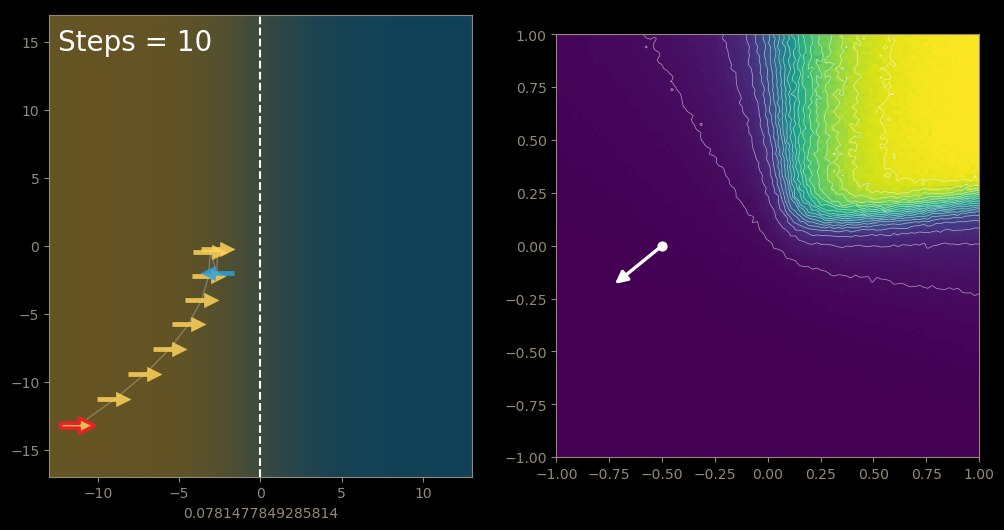

In [85]:
for k in tqdm(range(len(eps))):

    plt.clf()
    fig=plt.figure(0, (12, 6), facecolor='k')
    ax=fig.add_subplot(121, facecolor='k')
    ax2=fig.add_subplot(122, facecolor='k')
    
    ep=eps[k]
    obs_e, act_e = ep['obs'], ep['act']
    ang, angvel = np.degrees(obs_e[:, 2]), np.degrees(obs_e[:, 3])
    A, V = np.meshgrid(np.linspace(*ANG_LIM, 160), np.linspace(*VEL_LIM, 160))
    P_right_grid = 1 / (1 + np.exp(-(t1 * A + t2 * V)))
    ax.imshow(P_right_grid, origin='lower', cmap=cmap, vmin=0, vmax=1,
              extent=[*ANG_LIM, *VEL_LIM], aspect='auto', alpha=0.4)
    ax.contour(A, V, P_right_grid, levels=[0.5], colors='w', linestyles='--', linewidths=1.5)
    ax.plot(ang, angvel, color='w', lw=1.0, alpha=0.25, zorder=3, solid_capstyle='round')
    m = act_e == 1
    ax.scatter(ang[m],  angvel[m],  marker=RIGHT_ARROW, s=600, color=YELLOW, alpha=0.85, linewidths=0, zorder=4)
    ax.scatter(ang[~m], angvel[~m], marker=LEFT_ARROW,  s=600, color=BLUE,   alpha=0.85, linewidths=0, zorder=4)
    made_it = len(act_e) == 500
    ax.scatter([ang[-1]], [angvel[-1]],
               marker=(RIGHT_ARROW if act_e[-1]==1 else LEFT_ARROW), s=600,
               facecolors='none', edgecolors=('w' if made_it else RED), linewidths=2.5, zorder=5)
    ax.text(0.02, 0.97, f'Steps = {len(act_e)}', transform=ax.transAxes,
            ha='left', va='top', color='w', fontsize=20)
    ax.set_xlim(*ANG_LIM); ax.set_ylim(*VEL_LIM)
    # ax.set_xlabel('pole angle (degrees)'); ax.set_ylabel('pole angular velocity')
    # ax.set_title('State Space'); 
    style_ax(ax)
    ax.set_xlabel(eps[k]['prob'], color=CHILL_BROWN)
    # plt.axis('off')
    
    ax2=fig.add_subplot(122, facecolor='k')
    extent=np.array([theta1_vals_viz[0], theta1_vals_viz[-1], theta2_vals_viz[0], theta2_vals_viz[-1]])
    # im = ax.imshow(np.log(avg_reward.T), origin='lower', cmap='viridis',extent=np.radians(extent), aspect='equal') 
    im = ax2.imshow(avg_reward.T, origin='lower', cmap='viridis',extent=np.radians(extent), aspect='equal') 
    T1, T2 = np.meshgrid(np.radians(theta1_vals_viz), np.radians(theta2_vals_viz))
    cs = ax2.contour(T1, T2, avg_reward.T, levels=20, colors='w', linewidths=0.5, alpha=0.6)
    
    
    viz_scale=0.3
    grad=eps[k]['grad_prob']
    ax2.annotate('', xy=np.array([t1, t2]) + viz_scale*grad/np.linalg.norm(grad), xytext=(t1, t2), #zorder=7,
                arrowprops=dict(arrowstyle='-|>', color='w', lw=2.4, mutation_scale=18))
    
    ax2.scatter(t1, t2, c='w', s=40)
    style_ax(ax2)

    fig.savefig(save_dir + '/' + str(k).zfill(4) + '.png', dpi=240, facecolor='k')